In [1]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import hadamard

import graph_state.graph_state as gs
from experiment_module.experiment_results_processor import load_bsqn_incremental_sampling_data
from experiment_module.incremental import bell_diagonal_incremental_scalability_experiment

# Exploring the scalability of the BSQN protocol

These experiments give us some idea as to how the upper and lower bounds of the
BSQN protocol behave.

## I. Generating data for the $\mathcal{l}_2$-norm

Here, we compute the average minimum number of samples to get $\| \Delta \mathbf{a} \|_2 \le \epsilon$.
The curves should be non-increasing with respect to $n$, showing that the upper bound does
not depend on the graph state size.

In [ ]:
norm_order = 2
repeats = 200
output_dir = f"simulation_data/incremental_norm_{norm_order}"
incremental_step = 5
initial_sample_size = 500

results = bell_diagonal_incremental_scalability_experiment(
    graphs=[gs.GraphState(i, "complete") for i in range(2, 21)],
    err_model=["depolarizing", "single-qubit-dephasing", "bimodal"],
    fidelity=[0.51, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0],
    epsilon=[0.05],
    num_repeats=repeats,
    norm_order=norm_order,
    output_dir=output_dir,
    overwrite=False,
    incremental_step=incremental_step,
    initial_sample_size=initial_sample_size,
)

## II. Generating data for the $\mathcal{l}_1$-norm

The $\mathcal{l}_1$-norm should be way, way worse. (This experiment may not be run in full;
I imagine that the complexity for it is very ugly.)

In [ ]:
norm_order = 1
repeats = 200
output_dir = f"simulation_data/incremental_norm_{norm_order}"
incremental_step = 10
initial_sample_size = 1000

results = bell_diagonal_incremental_scalability_experiment(
    graphs=[gs.GraphState(i, "complete") for i in range(2, 21)],
    err_model=["depolarizing", "single-qubit-dephasing", "bimodal"],
    fidelity=[0.51, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0],
    epsilon=[0.05],
    num_repeats=repeats,
    norm_order=norm_order,
    output_dir=output_dir,
    overwrite=False,
    incremental_step=incremental_step,
    initial_sample_size=initial_sample_size,
)

## III. Retrieving the data

In [2]:
df_l2 = load_bsqn_incremental_sampling_data("simulation_data/incremental_norm_2")
df_l2

,qubits,error_type,fidelity,epsilon,norm_order,delta_a_norm,repeat,total_samples
0,2,single-qubit-dephasing,0.55,0.05,2,0.048764,181,1100
1,15,single-qubit-dephasing,0.60,0.05,2,0.046950,60,420
2,17,single-qubit-dephasing,0.60,0.05,2,0.047245,27,510
3,7,depolarizing,0.95,0.05,2,0.042288,153,90
4,17,depolarizing,0.75,0.05,2,0.049272,151,290
...,...,...,...,...,...,...,...,...
109944,8,single-qubit-dephasing,0.60,0.05,2,0.049288,68,542
109945,7,single-qubit-dephasing,0.55,0.05,2,0.049226,180,1220
109946,8,single-qubit-dephasing,0.55,0.05,2,0.049403,183,960
109947,8,bimodal,1.00,0.05,2,NaN,93,0


## IV. Plotting the results

This plot is more of a draft. The plots in the final report will be done using native
$\LaTeX$ tools and a CSV file with the results.

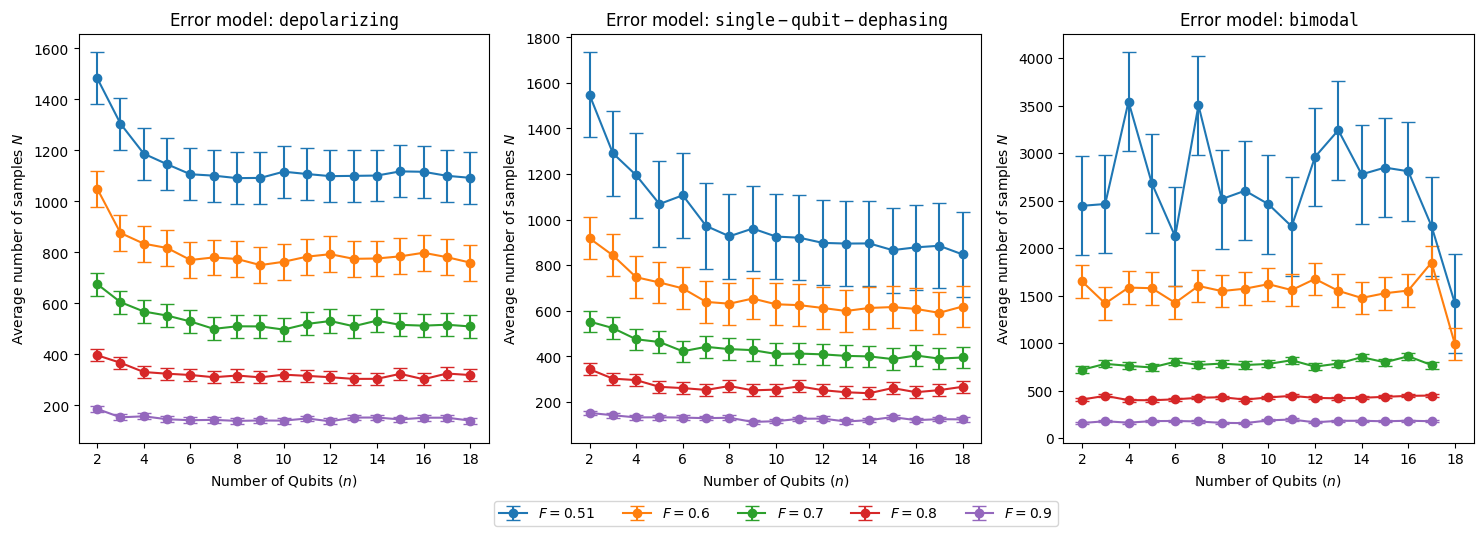

In [3]:
err_models = ["depolarizing", "single-qubit-dephasing", "bimodal"]
fidelities = [0.51, 0.6, 0.7, 0.8, 0.9]

fig, axes = plt.subplots(
    1,
    len(err_models),
    figsize=(6 * len(err_models), 9),
    # sharey=True,
    # sharex=True,
)

for j, err_model in enumerate(err_models):
    for k, fidelity in enumerate(fidelities):
        df_l2_filtered = df_l2[
            (df_l2["error_type"] == err_model) &
            (df_l2["fidelity"] == fidelity)
        ].groupby("qubits")

        samples = df_l2_filtered["total_samples"].mean()
        stds = samples.std()
        
        axes[j].errorbar(
            samples.index,
            samples.values,
            yerr=stds,
            marker="o",
            capsize=5,
            label=f"$F = {fidelity}$",
        )

        axes[j].set_title(rf"Error model: $\mathtt{{{err_model}}}$")
        axes[j].set_xlabel("Number of Qubits ($n$)")
        axes[j].set_ylabel(r"Average number of samples $N$")

        box = axes[j].get_position()
        axes[j].set_position(
            [box.x0, box.y0 + box.height * 0.1, box.width, box.height * 0.9]
        )

axes[1].legend(
    loc='upper center', bbox_to_anchor=(0.5, -0.125),
    fancybox=True, ncol=len(fidelities)
)

plt.show()

## Interlude. Analyzing the $P$ matrix

While developing the proof for the $n$-independent upper bound, I ended up investigating
many properties of the $P$ matrix that transforms the Bell sampling measurements $\mathbf{m}$
into the averages for each stabilizer $\mathbf{c}$. The main result can be found in
Proposition 1 of the report: $P \in \{-1, 1\}^{2^{n} \times 2^{2n}}$ is an unnormalized
partial Hadamard matrix where its rows sum up to a row vector where each element is either
$0$ or $2^n$.

In [4]:
def get_stabilizers(g: gs.GraphState) -> list[str]:
    """List all stabilizers (as strings) for a given graph state."""
    return ["I" * g.n] + [
        "".join("XZYI"[s.tolist()[i::g.n].index(True) if any(s.tolist()[i::g.n]) else -1] for i in range(g.n))
        for s in g.generate_all_int_stabilizers()
    ]


def get_phm_indices(g: gs.GraphState) -> list[int]:
    """Get the row indices for the P matrix of a given state."""
    stabilizers = get_stabilizers(g)
    base_operators = ["II", "XX", "ZZ", "YY"]
    candidates = ["".join(e) for e in product(base_operators, repeat=g.n)]
    operators = ["".join(2 * c for c in s) for s in stabilizers]
    return sorted([candidates.index(o) for o in operators])


def check_row_sum(g: gs.GraphState) -> None:
    """Test if the rows of a given state's P matrix sum up to 0 or 2^n."""
    indices = get_phm_indices(g)
    row_sum = hadamard(2 ** (2 * g.n))[indices, :].sum(axis=0)
    return all(x in (0.0, float(2 ** g.n)) for x in row_sum)

In [5]:
check_row_sum(gs.GraphState(6, graph_type="random-tree"))

True

Another very useful experiment is to see how the norm of error vectors behave
when multiplied by $P$. In this case, we want to check that if $\|\Delta\mathbf{m}\|_2 = \epsilon$,
then $\| P \Delta \mathbf{m} \|_2 \approx \sqrt{2^n} \epsilon$. This is the relation used to prove
the $n$-independent upper bound.

In [6]:
def create_delta_m(n: int) -> np.ndarray:
    """Create dm from a distribution and an estimation of it."""
    rng = np.random.default_rng()
    dist_original = rng.random((2 ** n) ** 2)
    dist_original = dist_original / np.linalg.norm(dist_original, ord=1)

    N = 100
    samples = np.random.choice((2 ** n) ** 2, N, p=dist_original).tolist()
    dist_estimation = np.array([samples.count(i) for i in np.arange((2 ** n) ** 2)]) / N
    return dist_original - dist_estimation

In [7]:
n_trials = 200

for n in range(3, 8):
    # Get the partial Hadamard matrix...
    g = gs.GraphState(n, graph_type="complete")
    indices = get_phm_indices(g)
    h = hadamard(2 ** (2 * n))[indices, :]

    # And generate a bunch of dms and check the average distortion
    average = 0
    for _ in range(n_trials):
        estimation = create_delta_m(n)
        average += np.linalg.norm(h.dot(estimation), ord=2) / np.linalg.norm(estimation, ord=2)

    # Ideally, for large enough n_trials, distortion <= sqrt(2 ** n)
    print(f"n = {n}, nrows = {2 ** n}, sqrt(nrows) = {np.sqrt(2 ** n)}, distortion: {average / n_trials}")

n = 3, nrows = 8, sqrt(nrows) = 2.8284271247461903, distortion: 2.5602645213369146
n = 4, nrows = 16, sqrt(nrows) = 4.0, distortion: 3.802326942689088
n = 5, nrows = 32, sqrt(nrows) = 5.656854249492381, distortion: 5.561962436370404
n = 6, nrows = 64, sqrt(nrows) = 8.0, distortion: 7.805542653512695
n = 7, nrows = 128, sqrt(nrows) = 11.313708498984761, distortion: 11.278588230323933
